In [268]:

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression

from sklearn.metrics import r2_score
from xgboost import XGBRegressor

In [253]:
df = pd.read_csv(r'train.csv')
df.shape
df["SalePrice"].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

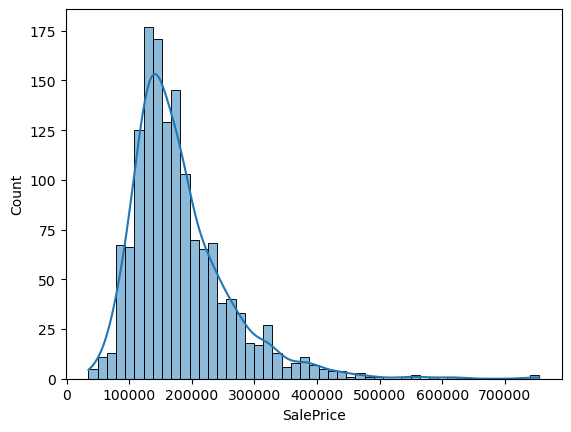

In [254]:

import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df["SalePrice"],kde=True)
plt.show()

In [255]:
missing = df.isnull().sum().sort_values(ascending=False)
print(missing.head(15))

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageYrBlt       81
GarageCond        81
GarageType        81
GarageFinish      81
GarageQual        81
BsmtFinType2      38
BsmtExposure      38
BsmtQual          37
dtype: int64


In [277]:
df.sample(2)
df = df.drop(columns = [
    'PoolQC','Fence','MiscFeature','MiscVal','MoSold','Alley','FireplaceQu','MasVnrType'])

KeyError: "['PoolQC', 'Fence', 'MiscFeature', 'MiscVal', 'MoSold', 'Alley', 'FireplaceQu', 'MasVnrType'] not found in axis"

## Scaling data 

In [278]:

ohe_columns = [
    "MSSubClass",
    "MSZoning",
    "Street",
    "LotShape",
    "LandContour",
    "LotConfig",
    "LandSlope",
    "Utilities",
    "Neighborhood",
    "Condition1",
    "Condition2",
    "BldgType",
    "HouseStyle",
    "RoofStyle",
    "RoofMatl",
    "Exterior1st",
    "Exterior2nd",
    "Foundation",
    "BsmtExposure",
    "BsmtFinType1",
    "BsmtFinType2",
    "Heating",
    "CentralAir",
    "Electrical",
    "GarageType",
    "GarageFinish",
    "PavedDrive",
    "SaleType",
    "SaleCondition"
]

ordinal_columns = [
    "ExterQual",
    "ExterCond",
    "BsmtQual",
    "BsmtCond",
    "HeatingQC",
    "KitchenQual",
    "GarageQual",
    "GarageCond"
]


X = df.drop(columns=["SalePrice"])
y = df["SalePrice"]

num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()




## Splitting for test and train



In [279]:
x_tr,x_tst,y_tr,y_tst = train_test_split(
    X,y,test_size= 0.2,random_state= 41
)

In [280]:

xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)


## Column transformer 

In [ ]:
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols)
])



## Fitting the data in pipeline

In [282]:
pipe = Pipeline([
    ("preprocessing", preprocessor),
    ("model", xgb_model)
])

In [283]:
pipe.fit(x_tr, y_tr)
y_pred = pipe.predict(x_tst)

## Predicting and calculating R2_score

In [284]:

score = r2_score(y_tst, y_pred)

print("R2 Score:", score)

R2 Score: 0.9008491039276123


In [285]:
x_tr.sample(2)

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,...,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,YrSold,SaleType,SaleCondition
1005,80,RL,65.0,8385,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,Y,210,0,0,0,0,0,2008,WD,Normal
1224,60,RL,60.0,15384,Pave,IR1,Lvl,AllPub,Inside,Gtl,...,Y,100,75,0,0,0,0,2008,WD,Normal


In [275]:
df

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,61,0,0,0,0,2008,WD,Normal,208500
1,20,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,Gtl,...,298,0,0,0,0,0,2007,WD,Normal,181500
2,60,RL,68.0,11250,Pave,IR1,Lvl,AllPub,Inside,Gtl,...,0,42,0,0,0,0,2008,WD,Normal,223500
3,70,RL,60.0,9550,Pave,IR1,Lvl,AllPub,Corner,Gtl,...,0,35,272,0,0,0,2006,WD,Abnorml,140000
4,60,RL,84.0,14260,Pave,IR1,Lvl,AllPub,FR2,Gtl,...,192,84,0,0,0,0,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,60,RL,62.0,7917,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,40,0,0,0,0,2007,WD,Normal,175000
1456,20,RL,85.0,13175,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,349,0,0,0,0,0,2010,WD,Normal,210000
1457,70,RL,66.0,9042,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,60,0,0,0,0,2010,WD,Normal,266500
1458,20,RL,68.0,9717,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,366,0,112,0,0,0,2010,WD,Normal,142125


In [291]:
test_df = pd.read_csv("test.csv")

test_ids = test_df["Id"]

test_predictions = pipe.predict(test_df)

submission = pd.DataFrame({
    "Id": test_ids,
    "SalePrice": test_predictions
})

submission.to_csv(r"C:\Users\Krish\Desktop\submission.csv", index=False)

In [ ]:
test_df = pd.read_csv("test.csv")

test_ids = test_df["Id"]

test_predictions = pipe.predict(test_df)

submission = pd.DataFrame({
    "Id": test_ids,
    "SalePrice": test_predictions
})

submission.to_csv("submission.csv", index=False)

NameError: name 'pd' is not defined

In [302]:
import tempfile, os

path = os.path.join(tempfile.gettempdir(), "submission.csv")
submission.to_csv(path, index=False)

print("Saved to:", path)

Saved to: C:\Users\Krish\AppData\Local\Temp\submission.csv
